# Fusão Multimodal — Features Visuais Otimizadas
Dois experimentos:
1. **Fusão B com AU+BS combinadas** (melhores features da análise estatística)
2. **Fusão B com Blendshapes no lugar das AUs**

Comparar com Fusão B original (só AUs) que deu Test F1 = 0.7090

In [1]:
# CÉLULA 1: Imports e configuração
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from sklearn.metrics import f1_score, classification_report
from scipy import stats as sp_stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = r'C:\Users\ddonz\OneDrive\Documentos\Aislan\data'
SPLIT_DIR = os.path.join(BASE_DIR, 'split')
AU_DIR = os.path.join(BASE_DIR, 'au_features')
BS_DIR = os.path.join(BASE_DIR, 'blendshape_features')
AUDIO_DIR = os.path.join(BASE_DIR, 'audio_features')

EXCLUDED_IDS = set(str(x) for x in [
    82723, 82687, 82569, 82570, 82576, 82577, 82581, 82587, 82589,
    82624, 82627, 82628, 82642, 82652, 82664, 82665, 82674, 82677,
    82681, 82690, 82705, 82708, 82709, 82738, 82758, 82768,
    82777, 82783, 82784, 82794, 82807, 82812, 82813, 82814,
    82815, 82817, 82819, 82820, 82832, 82845, 82861, 82866,
    82875, 82879, 82895, 82899, 82910, 82912, 82919, 82555,
    82786, 82827, 82927, 82928, 82956, 82968, 83008, 83011,
    83045, 83080, 83086
])

AU_NAMES = [
    'AU01', 'AU02', 'AU04', 'AU05', 'AU06', 'AU07', 'AU09', 'AU10',
    'AU11', 'AU12', 'AU14', 'AU15', 'AU17', 'AU20', 'AU23', 'AU24',
    'AU25', 'AU26', 'AU28', 'AU43'
]

BS_NAMES = [
    '_neutral', 'browDownLeft', 'browDownRight', 'browInnerUp', 'browOuterUpLeft',
    'browOuterUpRight', 'cheekPuff', 'cheekSquintLeft', 'cheekSquintRight',
    'eyeBlinkLeft', 'eyeBlinkRight', 'eyeLookDownLeft', 'eyeLookDownRight',
    'eyeLookInLeft', 'eyeLookInRight', 'eyeLookOutLeft', 'eyeLookOutRight',
    'eyeLookUpLeft', 'eyeLookUpRight', 'eyeSquintLeft', 'eyeSquintRight',
    'eyeWideLeft', 'eyeWideRight', 'jawForward', 'jawLeft', 'jawOpen',
    'jawRight', 'mouthClose', 'mouthDimpleLeft', 'mouthDimpleRight',
    'mouthFrownLeft', 'mouthFrownRight', 'mouthFunnel', 'mouthLeft',
    'mouthLowerDownLeft', 'mouthLowerDownRight', 'mouthPressLeft',
    'mouthPressRight', 'mouthPucker', 'mouthRight', 'mouthRollLower',
    'mouthRollUpper', 'mouthShrugLower', 'mouthShrugUpper', 'mouthSmileLeft',
    'mouthSmileRight', 'mouthStretchLeft', 'mouthStretchRight', 'mouthUpperUpLeft',
    'mouthUpperUpRight', 'noseSneerLeft', 'noseSneerRight'
]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [3]:
# CÉLULA 2: Selecionar melhores features da análise estatística
# Baseado nos resultados do Mann-Whitney U (top por effect size |r| > 0.10)
#
# Top AUs (Bonferroni): AU06, AU09, AU12, AU02, AU07, AU26
# Top BS (Bonferroni): browDownL/R, eyeLookOutR, mouthSmileL/R, eyeLookDownL/R,
#                       eyeLookInL, cheekPuff, eyeSquintL/R, mouthDimpleL/R
#
# Selecionar índices das features mais discriminativas:

# Top 10 AUs por effect size (índices no array de 20 AUs)
SELECTED_AU_INDICES = [
    5,   # AU06 (cheek raiser) — std e mean top
    6,   # AU09 (nose wrinkler) — std e mean top
    9,   # AU12 (lip corner puller / smile) — std e mean top
    1,   # AU02 (outer brow raiser) — std top
    5,   # AU07 (lid tightener) — std e mean
    17,  # AU26 (jaw drop) — zcr top
    0,   # AU01 (inner brow raiser)
    2,   # AU04 (brow lowerer)
    11,  # AU15 (lip corner depressor)
    19,  # AU43 (eye closure)
]
# Remover duplicatas mantendo ordem
SELECTED_AU_INDICES = list(dict.fromkeys(SELECTED_AU_INDICES))

# Top 15 BS por effect size (índices no array de 52 BS)
SELECTED_BS_INDICES = [
    1,   # browDownLeft — std top 1
    2,   # browDownRight — std top 4
    16,  # eyeLookOutRight — std
    44,  # mouthSmileLeft — std e mean
    45,  # mouthSmileRight — std e mean
    12,  # eyeLookDownRight — std
    11,  # eyeLookDownLeft — std
    13,  # eyeLookInLeft — std
    6,   # cheekPuff — zcr top
    19,  # eyeSquintLeft — std
    20,  # eyeSquintRight — std
    28,  # mouthDimpleLeft — std
    29,  # mouthDimpleRight — std
    15,  # eyeLookOutLeft — std
    9,   # eyeBlinkLeft — std
]

COMBINED_DIM = len(SELECTED_AU_INDICES) + len(SELECTED_BS_INDICES)

print(f"AUs selecionadas: {len(SELECTED_AU_INDICES)} → {[AU_NAMES[i] for i in SELECTED_AU_INDICES]}")
print(f"BS selecionados: {len(SELECTED_BS_INDICES)} → {[BS_NAMES[i] for i in SELECTED_BS_INDICES]}")
print(f"Dimensão visual combinada: {COMBINED_DIM}")
print(f"Dimensão só BS (todas): 52")

AUs selecionadas: 9 → ['AU07', 'AU09', 'AU12', 'AU02', 'AU26', 'AU01', 'AU04', 'AU15', 'AU43']
BS selecionados: 15 → ['browDownLeft', 'browDownRight', 'eyeLookOutRight', 'mouthSmileLeft', 'mouthSmileRight', 'eyeLookDownRight', 'eyeLookDownLeft', 'eyeLookInLeft', 'cheekPuff', 'eyeSquintLeft', 'eyeSquintRight', 'mouthDimpleLeft', 'mouthDimpleRight', 'eyeLookOutLeft', 'eyeBlinkLeft']
Dimensão visual combinada: 24
Dimensão só BS (todas): 52


In [4]:
# CÉLULA 3: Carregar splits com AU + BS + Audio + Texto

def load_split_full(split_file, au_dir, bs_dir, audio_dir, excluded_ids):
    data = []
    missing = {'au': 0, 'bs': 0, 'audio': 0, 'excluded': 0}
    
    with open(split_file, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(',', 2)
            if len(parts) < 2:
                continue
            
            video_path = parts[0]
            label = int(parts[1])
            text = parts[2] if len(parts) > 2 else ''
            
            path_parts = video_path.replace('\\', '/').split('/')
            pid = path_parts[1]
            video_name = path_parts[-1].replace('.mp4', '')
            
            if pid in excluded_ids:
                missing['excluded'] += 1
                continue
            
            # Encontrar arquivos .npy
            def find_npy(base_dir, pid, video_name):
                for suffix in [f'{video_name}.mp4.npy', f'{video_name}.npy']:
                    p = os.path.join(base_dir, pid, suffix)
                    if os.path.exists(p):
                        return p
                return None
            
            au_path = find_npy(au_dir, pid, video_name)
            bs_path = find_npy(bs_dir, pid, video_name)
            audio_path = find_npy(audio_dir, pid, video_name)
            
            if au_path is None:
                missing['au'] += 1; continue
            if bs_path is None:
                missing['bs'] += 1; continue
            if audio_path is None:
                missing['audio'] += 1; continue
            
            data.append({
                'pid': pid, 'video_name': video_name,
                'au_path': au_path, 'bs_path': bs_path,
                'audio_path': audio_path, 'text': text, 'label': label
            })
    
    return data, missing

train_data, train_miss = load_split_full(
    os.path.join(SPLIT_DIR, 'train.txt'), AU_DIR, BS_DIR, AUDIO_DIR, EXCLUDED_IDS)
val_data, val_miss = load_split_full(
    os.path.join(SPLIT_DIR, 'val.txt'), AU_DIR, BS_DIR, AUDIO_DIR, EXCLUDED_IDS)
test_data, test_miss = load_split_full(
    os.path.join(SPLIT_DIR, 'test.txt'), AU_DIR, BS_DIR, AUDIO_DIR, EXCLUDED_IDS)

for name, data, miss in [('Train', train_data, train_miss),
                          ('Val', val_data, val_miss),
                          ('Test', test_data, test_miss)]:
    labels = [d['label'] for d in data]
    print(f"{name}: {len(data)} vídeos | AH={sum(labels)} ({sum(labels)/len(labels)*100:.1f}%) | "
          f"Missing: {miss}")

Train: 598 vídeos | AH=297 (49.7%) | Missing: {'au': 0, 'bs': 0, 'audio': 0, 'excluded': 180}
Val: 107 vídeos | AH=65 (60.7%) | Missing: {'au': 0, 'bs': 0, 'audio': 0, 'excluded': 17}
Test: 427 vídeos | AH=256 (60.0%) | Missing: {'au': 0, 'bs': 0, 'audio': 0, 'excluded': 98}


In [5]:
# CÉLULA 4: Dataset Multimodal com 3 modos visuais

class MultimodalDatasetV2(Dataset):
    def __init__(self, data_list, tokenizer, visual_mode='combined',
                 au_max_len=256, audio_max_len=512, text_max_len=128,
                 visual_stats=None):
        """
        visual_mode: 'au_only' (20), 'bs_only' (52), 'combined' (selected AU+BS)
        """
        self.tokenizer = tokenizer
        self.visual_mode = visual_mode
        self.au_max_len = au_max_len
        self.audio_max_len = audio_max_len
        self.text_max_len = text_max_len
        self.items = []
        
        visual_arrays = []
        for item in data_list:
            au = np.load(item['au_path']).astype(np.float64)
            au = np.nan_to_num(au, nan=0.0, posinf=1.0, neginf=0.0)
            au = np.clip(au, 0.0, 5.0)
            
            bs = np.load(item['bs_path']).astype(np.float64)
            bs = np.nan_to_num(bs, nan=0.0, posinf=1.0, neginf=0.0)
            
            # Alinhar tamanhos
            min_len = min(len(au), len(bs))
            if min_len == 0:
                continue
            au = au[:min_len]
            bs = bs[:min_len]
            
            # Montar visual conforme modo
            if visual_mode == 'au_only':
                visual = au  # (N, 20)
            elif visual_mode == 'bs_only':
                visual = bs  # (N, 52)
            elif visual_mode == 'combined':
                au_selected = au[:, SELECTED_AU_INDICES]  # (N, ~10)
                bs_selected = bs[:, SELECTED_BS_INDICES]  # (N, ~15)
                visual = np.hstack([au_selected, bs_selected])  # (N, ~25)
            
            visual_arrays.append(visual)
            self.items.append({
                'visual': visual,
                'audio_path': item['audio_path'],
                'text': item['text'],
                'label': item['label']
            })
        
        self.visual_dim = visual_arrays[0].shape[1]
        
        # Normalização visual
        if visual_stats is None:
            all_frames = np.vstack(visual_arrays)
            self.v_mean = np.mean(all_frames, axis=0)
            self.v_std = np.std(all_frames, axis=0)
            self.v_std[self.v_std < 1e-8] = 1.0
        else:
            self.v_mean, self.v_std = visual_stats
    
    def get_visual_stats(self):
        return (self.v_mean, self.v_std)
    
    def _pad_or_truncate(self, seq, max_len):
        seq_len = len(seq)
        dim = seq.shape[1]
        if seq_len > max_len:
            indices = np.linspace(0, seq_len - 1, max_len, dtype=int)
            return seq[indices], np.ones(max_len)
        else:
            pad_len = max_len - seq_len
            padded = np.vstack([seq, np.zeros((pad_len, dim))])
            mask = np.concatenate([np.ones(seq_len), np.zeros(pad_len)])
            return padded, mask
    
    def __len__(self):
        return len(self.items)
    
    def __getitem__(self, idx):
        item = self.items[idx]
        
        visual = (item['visual'] - self.v_mean) / self.v_std
        v_padded, v_mask = self._pad_or_truncate(visual, self.au_max_len)
        
        audio = np.load(item['audio_path']).astype(np.float32)
        a_padded, a_mask = self._pad_or_truncate(audio, self.audio_max_len)
        
        encoding = self.tokenizer(
            item['text'], max_length=self.text_max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        
        return {
            'visual': torch.FloatTensor(v_padded),
            'visual_mask': torch.FloatTensor(v_mask),
            'audio': torch.FloatTensor(a_padded),
            'audio_mask': torch.FloatTensor(a_mask),
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.FloatTensor([item['label']])
        }

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
print("Tokenizer carregado.")

Tokenizer carregado.


In [6]:
# CÉLULA 5: Modelo Multimodal Fusão B (divergência) — visual_dim flexível

class FusionBModel(nn.Module):
    def __init__(self, visual_dim, hidden_dim=128, dropout=0.3, freeze_bert=True):
        super().__init__()
        proj_dim = hidden_dim
        
        # Visual encoder
        self.visual_lstm = nn.LSTM(
            input_size=visual_dim, hidden_size=hidden_dim,
            num_layers=2, batch_first=True,
            bidirectional=True, dropout=dropout
        )
        self.visual_attn = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64), nn.Tanh(), nn.Linear(64, 1)
        )
        self.visual_proj = nn.Linear(hidden_dim * 2, proj_dim)
        
        # Audio encoder
        self.audio_input_proj = nn.Linear(768, hidden_dim)
        self.audio_lstm = nn.LSTM(
            input_size=hidden_dim, hidden_size=hidden_dim,
            num_layers=2, batch_first=True,
            bidirectional=True, dropout=dropout
        )
        self.audio_attn = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64), nn.Tanh(), nn.Linear(64, 1)
        )
        self.audio_proj = nn.Linear(hidden_dim * 2, proj_dim)
        
        # Text encoder
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        if freeze_bert:
            for param in self.bert.parameters():
                param.requires_grad = False
            for param in self.bert.encoder.layer[-2:].parameters():
                param.requires_grad = True
        self.text_proj = nn.Linear(768, proj_dim)
        
        # Classifier — Fusão B: divergências only
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim * 3, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
    
    def _attend(self, lstm_out, mask, attn_layer):
        weights = attn_layer(lstm_out).squeeze(-1)
        weights = weights.masked_fill(mask == 0, float('-inf'))
        weights = torch.softmax(weights, dim=1)
        return torch.bmm(weights.unsqueeze(1), lstm_out).squeeze(1)
    
    def forward(self, visual, v_mask, audio, a_mask, input_ids, attention_mask):
        # Visual
        v_out, _ = self.visual_lstm(visual)
        h_v = self._attend(v_out, v_mask, self.visual_attn)
        h_v = self.visual_proj(h_v)
        
        # Audio
        a_proj = self.audio_input_proj(audio)
        a_out, _ = self.audio_lstm(a_proj)
        h_a = self._attend(a_out, a_mask, self.audio_attn)
        h_a = self.audio_proj(h_a)
        
        # Text
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        h_t = self.text_proj(bert_out.last_hidden_state[:, 0])
        
        # Fusão B: divergências
        d_va = torch.abs(h_v - h_a)
        d_vt = torch.abs(h_v - h_t)
        d_at = torch.abs(h_a - h_t)
        fused = torch.cat([d_va, d_vt, d_at], dim=1)
        
        return self.classifier(fused)

print("Modelo definido.")

Modelo definido.


In [7]:
# CÉLULA 6: Funções de treino e avaliação

def train_fusion(model, train_loader, val_loader, train_data,
                 n_epochs=30, lr=5e-4, patience=8, model_name='model'):
    
    n_pos = sum(d['label'] for d in train_data)
    n_neg = len(train_data) - n_pos
    pos_weight = torch.FloatTensor([n_neg / n_pos]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    bert_params = [p for n, p in model.named_parameters() if 'bert' in n and p.requires_grad]
    other_params = [p for n, p in model.named_parameters() if 'bert' not in n and p.requires_grad]
    optimizer = torch.optim.AdamW([
        {'params': bert_params, 'lr': lr * 0.1},
        {'params': other_params, 'lr': lr}
    ], weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    
    best_val_f1 = 0
    patience_counter = 0
    history = {'train_loss': [], 'val_f1': []}
    
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        n_batches = 0
        
        for batch in train_loader:
            v = batch['visual'].to(device)
            vm = batch['visual_mask'].to(device)
            a = batch['audio'].to(device)
            am = batch['audio_mask'].to(device)
            ids = batch['input_ids'].to(device)
            att = batch['attention_mask'].to(device)
            y = batch['label'].to(device)
            
            optimizer.zero_grad()
            logits = model(v, vm, a, am, ids, att)
            loss = criterion(logits, y)
            
            if torch.isnan(loss):
                continue
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1
        
        scheduler.step()
        avg_loss = total_loss / max(n_batches, 1)
        
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                v = batch['visual'].to(device)
                vm = batch['visual_mask'].to(device)
                a = batch['audio'].to(device)
                am = batch['audio_mask'].to(device)
                ids = batch['input_ids'].to(device)
                att = batch['attention_mask'].to(device)
                
                logits = model(v, vm, a, am, ids, att)
                preds = (torch.sigmoid(logits) > 0.5).float()
                all_preds.extend(preds.cpu().numpy().flatten())
                all_labels.extend(batch['label'].numpy().flatten())
        
        val_f1 = f1_score(all_labels, all_preds, average='macro')
        history['train_loss'].append(avg_loss)
        history['val_f1'].append(val_f1)
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
            torch.save(model.state_dict(), os.path.join(BASE_DIR, f'best_{model_name}.pt'))
        else:
            patience_counter += 1
        
        if (epoch + 1) % 3 == 0 or patience_counter == 0:
            print(f"  Epoch {epoch+1:3d} | Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f} "
                  f"| Best: {best_val_f1:.4f} {'*' if patience_counter == 0 else ''}")
        
        if patience_counter >= patience:
            print(f"  Early stopping na epoch {epoch+1}")
            break
    
    model.load_state_dict(torch.load(os.path.join(BASE_DIR, f'best_{model_name}.pt')))
    return model, history, best_val_f1


def evaluate_fusion(model, loader, split_name='Test'):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            v = batch['visual'].to(device)
            vm = batch['visual_mask'].to(device)
            a = batch['audio'].to(device)
            am = batch['audio_mask'].to(device)
            ids = batch['input_ids'].to(device)
            att = batch['attention_mask'].to(device)
            
            logits = model(v, vm, a, am, ids, att)
            preds = (torch.sigmoid(logits) > 0.5).float()
            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(batch['label'].numpy().flatten())
    
    f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"\n{split_name} Macro F1: {f1:.4f}")
    print(classification_report(all_labels, all_preds, target_names=['No AH', 'AH']))
    return f1

print("Funções prontas.")

Funções prontas.


In [8]:
# CÉLULA 7: EXPERIMENTO 1 — Fusão B com Blendshapes (52 dims) no lugar das AUs
print("=" * 60)
print("EXPERIMENTO 1: Fusão B — Blendshapes only (52 dims)")
print("=" * 60)

BATCH_SIZE = 16

train_ds_bs = MultimodalDatasetV2(
    train_data, tokenizer, visual_mode='bs_only')
vs_bs = train_ds_bs.get_visual_stats()
val_ds_bs = MultimodalDatasetV2(
    val_data, tokenizer, visual_mode='bs_only', visual_stats=vs_bs)
test_ds_bs = MultimodalDatasetV2(
    test_data, tokenizer, visual_mode='bs_only', visual_stats=vs_bs)

train_ld_bs = DataLoader(train_ds_bs, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_ld_bs = DataLoader(val_ds_bs, batch_size=BATCH_SIZE, num_workers=0)
test_ld_bs = DataLoader(test_ds_bs, batch_size=BATCH_SIZE, num_workers=0)

print(f"Visual dim: {train_ds_bs.visual_dim}")
print(f"Train: {len(train_ds_bs)} | Val: {len(val_ds_bs)} | Test: {len(test_ds_bs)}")

model_bs = FusionBModel(visual_dim=52, hidden_dim=128, dropout=0.3).to(device)
model_bs, hist_bs, val_f1_bs = train_fusion(
    model_bs, train_ld_bs, val_ld_bs, train_data,
    n_epochs=30, lr=5e-4, patience=8, model_name='fusionB_bs'
)
test_f1_bs = evaluate_fusion(model_bs, test_ld_bs, 'Fusão B (BS only)')

EXPERIMENTO 1: Fusão B — Blendshapes only (52 dims)
Visual dim: 52
Train: 598 | Val: 107 | Test: 427


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch   1 | Loss: 0.6821 | Val F1: 0.6154 | Best: 0.6154 *
  Epoch   3 | Loss: 0.4969 | Val F1: 0.6809 | Best: 0.6809 *
  Epoch   4 | Loss: 0.4146 | Val F1: 0.6965 | Best: 0.6965 *
  Epoch   5 | Loss: 0.3574 | Val F1: 0.7066 | Best: 0.7066 *
  Epoch   6 | Loss: 0.2893 | Val F1: 0.6975 | Best: 0.7066 
  Epoch   9 | Loss: 0.1022 | Val F1: 0.6306 | Best: 0.7066 
  Epoch  12 | Loss: 0.0185 | Val F1: 0.6531 | Best: 0.7066 
  Early stopping na epoch 13

Fusão B (BS only) Macro F1: 0.6798
              precision    recall  f1-score   support

       No AH       0.58      0.76      0.66       171
          AH       0.80      0.63      0.70       256

    accuracy                           0.68       427
   macro avg       0.69      0.69      0.68       427
weighted avg       0.71      0.68      0.68       427



In [9]:
# CÉLULA 8: EXPERIMENTO 2 — Fusão B com AU+BS combinadas (melhores features)
print("=" * 60)
print(f"EXPERIMENTO 2: Fusão B — AU+BS combinadas ({COMBINED_DIM} dims)")
print("=" * 60)

train_ds_comb = MultimodalDatasetV2(
    train_data, tokenizer, visual_mode='combined')
vs_comb = train_ds_comb.get_visual_stats()
val_ds_comb = MultimodalDatasetV2(
    val_data, tokenizer, visual_mode='combined', visual_stats=vs_comb)
test_ds_comb = MultimodalDatasetV2(
    test_data, tokenizer, visual_mode='combined', visual_stats=vs_comb)

train_ld_comb = DataLoader(train_ds_comb, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_ld_comb = DataLoader(val_ds_comb, batch_size=BATCH_SIZE, num_workers=0)
test_ld_comb = DataLoader(test_ds_comb, batch_size=BATCH_SIZE, num_workers=0)

print(f"Visual dim: {train_ds_comb.visual_dim}")
print(f"Train: {len(train_ds_comb)} | Val: {len(val_ds_comb)} | Test: {len(test_ds_comb)}")

model_comb = FusionBModel(visual_dim=COMBINED_DIM, hidden_dim=128, dropout=0.3).to(device)
model_comb, hist_comb, val_f1_comb = train_fusion(
    model_comb, train_ld_comb, val_ld_comb, train_data,
    n_epochs=30, lr=5e-4, patience=8, model_name='fusionB_combined'
)
test_f1_comb = evaluate_fusion(model_comb, test_ld_comb, 'Fusão B (AU+BS combined)')

EXPERIMENTO 2: Fusão B — AU+BS combinadas (24 dims)
Visual dim: 24
Train: 598 | Val: 107 | Test: 427


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch   1 | Loss: 0.6745 | Val F1: 0.5219 | Best: 0.5219 *
  Epoch   2 | Loss: 0.5952 | Val F1: 0.5473 | Best: 0.5473 *
  Epoch   3 | Loss: 0.4998 | Val F1: 0.6207 | Best: 0.6207 *
  Epoch   4 | Loss: 0.4292 | Val F1: 0.7266 | Best: 0.7266 *
  Epoch   6 | Loss: 0.2513 | Val F1: 0.6259 | Best: 0.7266 
  Epoch   9 | Loss: 0.0940 | Val F1: 0.6571 | Best: 0.7266 
  Epoch  12 | Loss: 0.0657 | Val F1: 0.6788 | Best: 0.7266 
  Early stopping na epoch 12

Fusão B (AU+BS combined) Macro F1: 0.6793
              precision    recall  f1-score   support

       No AH       0.58      0.75      0.65       171
          AH       0.79      0.64      0.71       256

    accuracy                           0.68       427
   macro avg       0.69      0.69      0.68       427
weighted avg       0.71      0.68      0.68       427



In [10]:
# CÉLULA 9: EXPERIMENTO 3 — Fusão B com AUs originais (referência)
print("=" * 60)
print("EXPERIMENTO 3: Fusão B — AUs only (20 dims) — referência")
print("=" * 60)

train_ds_au = MultimodalDatasetV2(
    train_data, tokenizer, visual_mode='au_only')
vs_au = train_ds_au.get_visual_stats()
val_ds_au = MultimodalDatasetV2(
    val_data, tokenizer, visual_mode='au_only', visual_stats=vs_au)
test_ds_au = MultimodalDatasetV2(
    test_data, tokenizer, visual_mode='au_only', visual_stats=vs_au)

train_ld_au = DataLoader(train_ds_au, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_ld_au = DataLoader(val_ds_au, batch_size=BATCH_SIZE, num_workers=0)
test_ld_au = DataLoader(test_ds_au, batch_size=BATCH_SIZE, num_workers=0)

print(f"Visual dim: {train_ds_au.visual_dim}")

model_au = FusionBModel(visual_dim=20, hidden_dim=128, dropout=0.3).to(device)
model_au, hist_au, val_f1_au = train_fusion(
    model_au, train_ld_au, val_ld_au, train_data,
    n_epochs=30, lr=5e-4, patience=8, model_name='fusionB_au'
)
test_f1_au = evaluate_fusion(model_au, test_ld_au, 'Fusão B (AU only)')

EXPERIMENTO 3: Fusão B — AUs only (20 dims) — referência
Visual dim: 20


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch   1 | Loss: 0.6759 | Val F1: 0.5859 | Best: 0.5859 *
  Epoch   3 | Loss: 0.5471 | Val F1: 0.5890 | Best: 0.5890 *
  Epoch   4 | Loss: 0.4341 | Val F1: 0.6306 | Best: 0.6306 *
  Epoch   5 | Loss: 0.3685 | Val F1: 0.6912 | Best: 0.6912 *
  Epoch   6 | Loss: 0.2670 | Val F1: 0.6668 | Best: 0.6912 
  Epoch   9 | Loss: 0.1171 | Val F1: 0.6556 | Best: 0.6912 
  Epoch  12 | Loss: 0.0262 | Val F1: 0.6389 | Best: 0.6912 
  Early stopping na epoch 13

Fusão B (AU only) Macro F1: 0.7010
              precision    recall  f1-score   support

       No AH       0.62      0.70      0.66       171
          AH       0.78      0.71      0.74       256

    accuracy                           0.71       427
   macro avg       0.70      0.71      0.70       427
weighted avg       0.72      0.71      0.71       427



RESULTADOS — Fusão B (Divergência) com diferentes features visuais
Modelo                                   Vis dim   Val F1  Test F1
-----------------------------------------------------------------
Challenge baseline                             —        —   0.2827
Fusão B original (prev run)                   20   0.6524   0.7090
-----------------------------------------------------------------
Fusão B — AUs only (re-run)                   20   0.6912   0.7010
Fusão B — Blendshapes only                    52   0.7066   0.6798
Fusão B — AU+BS combined (selected)           24   0.7266   0.6793


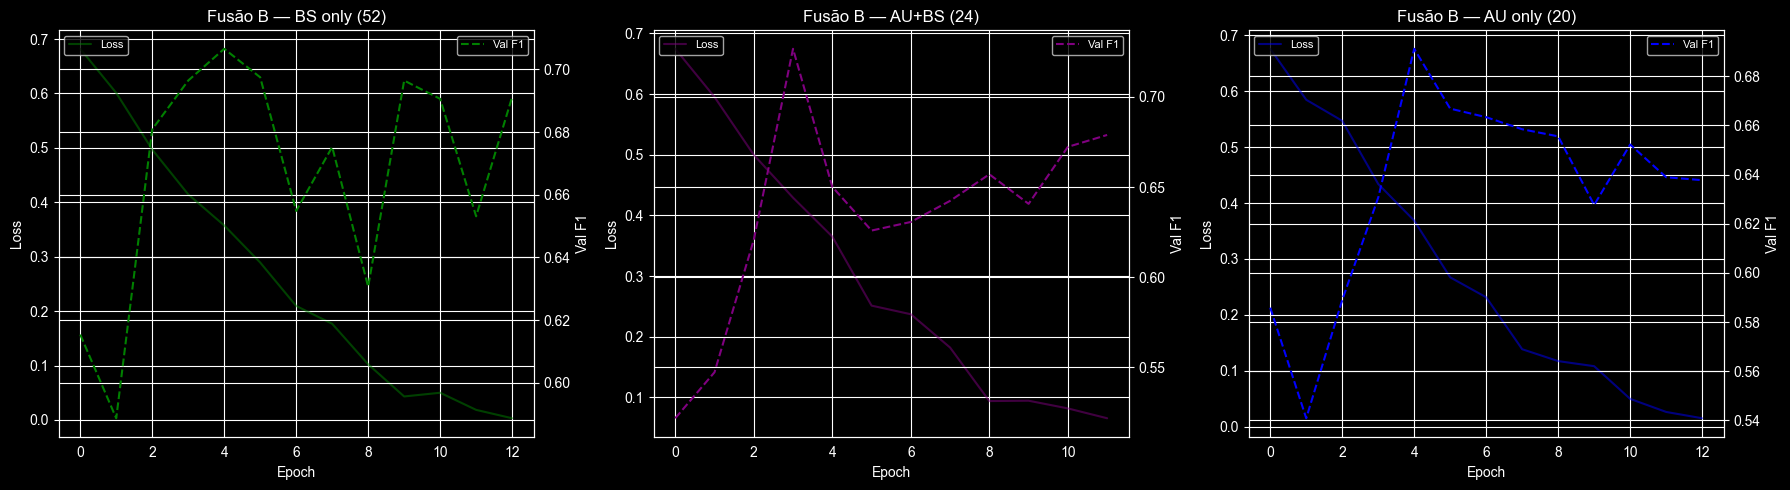

In [11]:
# CÉLULA 10: Comparativo final

print("=" * 65)
print("RESULTADOS — Fusão B (Divergência) com diferentes features visuais")
print("=" * 65)
print(f"{'Modelo':<40} {'Vis dim':>7} {'Val F1':>8} {'Test F1':>8}")
print("-" * 65)
print(f"{'Challenge baseline':<40} {'—':>7} {'—':>8} {'0.2827':>8}")
print(f"{'Fusão B original (prev run)':<40} {'20':>7} {'0.6524':>8} {'0.7090':>8}")
print("-" * 65)
print(f"{'Fusão B — AUs only (re-run)':<40} {'20':>7} {val_f1_au:>8.4f} {test_f1_au:>8.4f}")
print(f"{'Fusão B — Blendshapes only':<40} {'52':>7} {val_f1_bs:>8.4f} {test_f1_bs:>8.4f}")
print(f"{'Fusão B — AU+BS combined (selected)':<40} {COMBINED_DIM:>7} {val_f1_comb:>8.4f} {test_f1_comb:>8.4f}")
print("=" * 65)

# Gráficos de treino
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, hist, name, color in [
    (axes[0], hist_bs, 'BS only (52)', 'green'),
    (axes[1], hist_comb, f'AU+BS ({COMBINED_DIM})', 'purple'),
    (axes[2], hist_au, 'AU only (20)', 'blue'),
]:
    ax2 = ax.twinx()
    ax.plot(hist['train_loss'], color=color, alpha=0.5, label='Loss')
    ax2.plot(hist['val_f1'], color=color, linestyle='--', label='Val F1')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax2.set_ylabel('Val F1')
    ax.set_title(f'Fusão B — {name}')
    ax.legend(loc='upper left', fontsize=8)
    ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()